# Frequencia_Cor v1 — Treinamento
FFT + Cor RGB/HSV + Estatísticas PCA Invariantes + XGBoost

**Features (35 dims):** PCA invariante (6) | PCA escalar (6) | RGB (12) | HSV (6) | FFT (5)

---
## Setup

In [2]:
import random
import warnings
import json
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from io import BytesIO
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

from PIL import Image, ImageFile, ImageFilter, ImageEnhance
ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.MAX_IMAGE_PIXELS = None
warnings.filterwarnings('ignore', message='.*decompression bomb.*', category=UserWarning)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, brier_score_loss
)

from xgboost import XGBClassifier

In [3]:
# detecta a raiz do projeto pelo .git, independente de onde o notebook foi aberto
_here = Path('.').resolve()
PROJECT_ROOT = _here
while not (PROJECT_ROOT / '.git').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / 'modelos' / 'Frequencia_Cor'
CACHE_DIR  = PROJECT_ROOT / 'cache_freq_cor_v1'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_REAL = Path(r'D:\TCCDataset\train\real')
TRAIN_FAKE = Path(r'D:\TCCDataset\train\fake')
TEST_REAL  = Path(r'D:\TCCDataset\test\real')
TEST_FAKE  = Path(r'D:\TCCDataset\test\fake')

EXTENSIONS  = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
RESIZE_TO   = (128, 128)
N_PCA_COMP  = 30
RANDOM_SEED = 42

print(f'output : {OUTPUT_DIR}')
print(f'cache  : {CACHE_DIR}')

output : C:\Users\user\Desktop\TCC\Xiz9\modelos\Frequencia_Cor
cache  : C:\Users\user\Desktop\TCC\Xiz9\cache_freq_cor_v1


---
## Funções de extração

In [4]:
def _pca_distribution_features(eig: np.ndarray) -> list:
    # estatísticas invariantes à base — comparáveis entre imagens independentemente da direção dos componentes
    eig_sorted = np.sort(eig)[::-1]
    norm_eig   = eig_sorted / (eig_sorted.sum() + 1e-12)

    eigen_entropy = float(-np.sum(norm_eig * np.log(norm_eig + 1e-12)))
    top5_ratio    = float(eig_sorted[:5].sum() / (eig_sorted[-5:].sum() + 1e-12))

    cumsum = np.cumsum(norm_eig)
    n_50   = int(np.searchsorted(cumsum, 0.50) + 1)
    n_90   = int(np.searchsorted(cumsum, 0.90) + 1)
    n_95   = int(np.searchsorted(cumsum, 0.95) + 1)

    k     = np.arange(1, len(eig_sorted) + 1)
    slope = float(np.polyfit(np.log(k), np.log(eig_sorted + 1e-12), 1)[0])

    return [eigen_entropy, top5_ratio, n_50, n_90, n_95, slope]

In [5]:
def augment_image_bytes(image_bytes: bytes) -> bytes:
    img = Image.open(BytesIO(image_bytes)).convert('RGB')

    if random.random() < 0.5:
        scale = random.uniform(0.75, 1.25)
        img = img.resize((int(img.width * scale), int(img.height * scale)), Image.LANCZOS)

    if random.random() < 0.7:
        quality = random.randint(60, 95)
        buf = BytesIO()
        img.save(buf, format='JPEG', quality=quality)
        img = Image.open(BytesIO(buf.getvalue())).convert('RGB')

    if random.random() < 0.2:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 1.0)))

    if random.random() < 0.3:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.85, 1.15))
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.85, 1.15))

    out = BytesIO()
    img.save(out, format='PNG')
    return out.getvalue()

In [6]:
def _reconstruction_error(matrix, pca, scores, k):
    sk = np.zeros_like(scores)
    sk[:, :k] = scores[:, :k]
    return float(np.mean((matrix - pca.inverse_transform(sk)) ** 2))


def extract_freq_cor_features(image_bytes: bytes) -> np.ndarray | None:
    try:
        img_rgb  = Image.open(BytesIO(image_bytes)).convert('RGB').resize(RESIZE_TO)
        img_gray = img_rgb.convert('L')
        arr_rgb  = np.array(img_rgb,  dtype=np.float64) / 255.0
        arr_gray = np.array(img_gray, dtype=np.float64) / 255.0

        # PCA no canal cinza
        n      = min(N_PCA_COMP, min(arr_gray.shape))
        pca    = PCA(n_components=n, svd_solver='randomized', random_state=RANDOM_SEED)
        scores = pca.fit_transform(arr_gray)
        eig    = pca.explained_variance_
        evr    = pca.explained_variance_ratio_

        pca_inv_feats = _pca_distribution_features(eig)

        geo_mean  = float(np.exp(np.mean(np.log(eig + 1e-12))))
        spec_flat = geo_mean / (float(np.mean(eig)) + 1e-12)
        first_dom = float(evr[0])
        coef_var  = float(np.std(eig) / (np.mean(eig) + 1e-12))
        rec_k5    = _reconstruction_error(arr_gray, pca, scores, min(5,  n))
        rec_k10   = _reconstruction_error(arr_gray, pca, scores, min(10, n))
        pca_scalar_feats = [spec_flat, first_dom, coef_var, rec_k5, rec_k10,
                            _reconstruction_error(arr_gray, pca, scores, min(20, n))]

        # Cor RGB
        color_feats = []
        for c in range(3):
            ch = arr_rgb[:, :, c].ravel()
            mu = ch.mean()
            sd = ch.std() + 1e-12
            color_feats += [float(mu), float(sd),
                            float(np.mean(((ch - mu) / sd) ** 3)),
                            float(np.mean(((ch - mu) / sd) ** 4))]

        # Cor HSV
        try:
            arr_hsv = np.array(
                Image.open(BytesIO(image_bytes)).convert('RGB').resize(RESIZE_TO).convert('HSV'),
                dtype=np.float64
            ) / 255.0
            hsv_feats = []
            for c in range(3):
                ch = arr_hsv[:, :, c].ravel()
                hsv_feats += [float(np.mean(ch)), float(np.std(ch))]
        except Exception:
            hsv_feats = [0.0] * 6

        # FFT — fftshift desloca o DC para o centro, permitindo bandas radiais
        fft     = np.fft.fft2(arr_gray)
        fft_mag = np.abs(np.fft.fftshift(fft))

        h, w     = fft_mag.shape
        cy, cx   = h // 2, w // 2
        Y, X     = np.ogrid[:h, :w]
        dist     = np.sqrt((X - cx)**2 + (Y - cy)**2)
        max_dist = np.sqrt(cx**2 + cy**2)

        e_low   = float(np.sum(fft_mag[dist <= max_dist * 0.1] ** 2))
        e_mid   = float(np.sum(fft_mag[(dist > max_dist * 0.1) & (dist <= max_dist * 0.4)] ** 2))
        e_high  = float(np.sum(fft_mag[dist > max_dist * 0.4] ** 2))
        e_total = e_low + e_mid + e_high + 1e-12

        fft_feats = [
            e_low  / e_total,
            e_mid  / e_total,
            e_high / e_total,
            e_high / (e_low + 1e-12),
            float(np.std(np.log1p(fft_mag))),
        ]

        result = np.array(pca_inv_feats + pca_scalar_feats + color_feats + hsv_feats + fft_feats,
                          dtype=np.float32)
        return np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)

    except Exception:
        return None


# teste rápido
sample_files = [f for f in TRAIN_REAL.rglob('*') if f.suffix.lower() in EXTENSIONS]
assert len(sample_files) > 0, f'nenhuma imagem em {TRAIN_REAL}'
sample = extract_freq_cor_features(sample_files[0].read_bytes())
print(f'features: {len(sample)} dims | NaN: {np.isnan(sample).sum()} | Inf: {np.isinf(sample).sum()}')

features: 35 dims | NaN: 0 | Inf: 0


---
## Extração do dataset

In [7]:
def list_images(folder: Path) -> list:
    return [p for p in folder.rglob('*') if p.suffix.lower() in EXTENSIONS]


def _process_one(args):
    fpath, label, do_augment = args
    results = []
    try:
        raw  = fpath.read_bytes()
        feat = extract_freq_cor_features(raw)
        if feat is not None:
            results.append((feat, label))
        if do_augment:
            feat_aug = extract_freq_cor_features(augment_image_bytes(raw))
            if feat_aug is not None:
                results.append((feat_aug, label))
    except Exception:
        pass
    return results


def extract_split(real_folder, fake_folder, prefix, augment=False, n_workers=8):
    cache_X = CACHE_DIR / f'{prefix}_X.npy'
    cache_y = CACHE_DIR / f'{prefix}_y.npy'

    if cache_X.exists() and cache_y.exists():
        print(f'{prefix}: carregando do cache')
        return np.load(cache_X), np.load(cache_y)

    files = ([(f, 0, augment) for f in list_images(real_folder)] +
             [(f, 1, augment) for f in list_images(fake_folder)])

    print(f'{prefix}: {len(files)} imagens', '(+aug)' if augment else '')

    X, y = [], []
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        for results in tqdm(executor.map(_process_one, files), total=len(files), desc=prefix):
            for feat, label in results:
                X.append(feat)
                y.append(label)

    X_arr = np.array(X, dtype=np.float32)
    y_arr = np.array(y, dtype=np.int8)
    np.save(cache_X, X_arr)
    np.save(cache_y, y_arr)
    return X_arr, y_arr


X_train_full, y_train_full = extract_split(TRAIN_REAL, TRAIN_FAKE, 'train', augment=True)
X_test,       y_test       = extract_split(TEST_REAL,  TEST_FAKE,  'test',  augment=False)

print(f'train: {X_train_full.shape} | test: {X_test.shape}')

train: carregando do cache
test: carregando do cache
train: (96000, 35) | test: (12000, 35)


---
## Treino / Validação / Teste

In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_SEED
)

print(f'treino: {X_tr.shape[0]} | val: {X_val.shape[0]} | teste: {X_test.shape[0]}')

treino: 76800 | val: 19200 | teste: 12000


---
## Normalização

In [9]:
scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr)
X_val_s  = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

---
## XGBoost

In [10]:
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

xgb_model = XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = scale_pos_weight,
    eval_metric           = 'auc',
    early_stopping_rounds = 30,
    random_state          = RANDOM_SEED,
    n_jobs                = -1,
    verbosity             = 0,
)

xgb_model.fit(
    X_tr_s, y_tr,
    eval_set=[(X_val_s, y_val)],
    verbose=50
)

y_val_pred  = xgb_model.predict(X_val_s)
y_val_proba = xgb_model.predict_proba(X_val_s)[:, 1]

print(f'val  accuracy: {accuracy_score(y_val, y_val_pred):.4f}')
print(f'val  F1      : {f1_score(y_val, y_val_pred):.4f}')
print(f'val  AUC-ROC : {roc_auc_score(y_val, y_val_proba):.4f}')

[0]	validation_0-auc:0.74421
[50]	validation_0-auc:0.80468
[100]	validation_0-auc:0.82618
[150]	validation_0-auc:0.83987
[200]	validation_0-auc:0.84952
[250]	validation_0-auc:0.85759
[300]	validation_0-auc:0.86441
[350]	validation_0-auc:0.86955
[400]	validation_0-auc:0.87489
[450]	validation_0-auc:0.87960
[499]	validation_0-auc:0.88342
val  accuracy: 0.8007
val  F1      : 0.8060
val  AUC-ROC : 0.8834


---
## Calibração e limiar ótimo

brier score: 0.1376
threshold ótimo: 0.4556 | F1 val: 0.8116


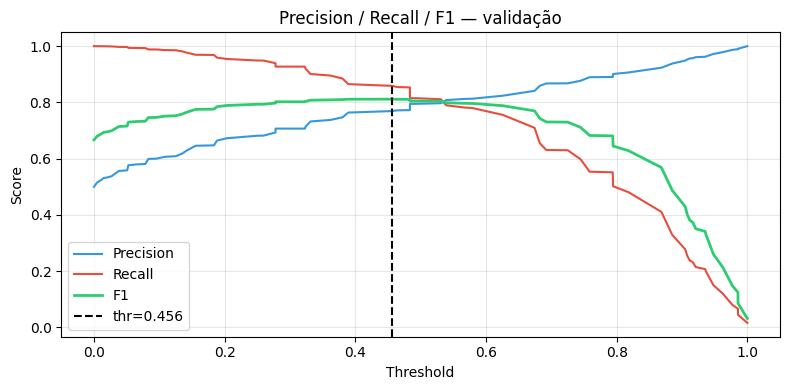

In [11]:
proba_val_raw = xgb_model.predict_proba(X_val_s)[:, 1]

calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(proba_val_raw, y_val)

proba_val_cal = calibrator.transform(proba_val_raw)
print(f'brier score: {brier_score_loss(y_val, proba_val_cal):.4f}')

prec, rec, thresholds = precision_recall_curve(y_val, proba_val_cal)
f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_idx  = int(np.argmax(f1_scores))
best_thr  = float(thresholds[best_idx])
best_f1   = float(f1_scores[best_idx])
print(f'threshold ótimo: {best_thr:.4f} | F1 val: {best_f1:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(thresholds, prec[:-1], label='Precision', color='#3498db')
plt.plot(thresholds, rec[:-1],  label='Recall',    color='#e74c3c')
plt.plot(thresholds, f1_scores, label='F1',        color='#2ecc71', linewidth=2)
plt.axvline(best_thr, color='black', linestyle='--', label=f'thr={best_thr:.3f}')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Precision / Recall / F1 — validação')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(CACHE_DIR / 'threshold_curve.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Avaliação no teste

In [12]:
proba_test_raw = xgb_model.predict_proba(X_test_s)[:, 1]
proba_test     = calibrator.transform(proba_test_raw)
y_pred_test    = (proba_test >= best_thr).astype(int)

acc = accuracy_score(y_test, y_pred_test)
f1  = f1_score(y_test, y_pred_test)
auc = roc_auc_score(y_test, proba_test)

print(f'accuracy : {acc:.4f}')
print(f'F1       : {f1:.4f}')
print(f'AUC-ROC  : {auc:.4f}')
print(f'threshold: {best_thr:.4f}')
print()
print(classification_report(y_test, y_pred_test, target_names=['Real', 'IA']))

accuracy : 0.7656
F1       : 0.7799
AUC-ROC  : 0.8477
threshold: 0.4556

              precision    recall  f1-score   support

        Real       0.81      0.70      0.75      6000
          IA       0.73      0.83      0.78      6000

    accuracy                           0.77     12000
   macro avg       0.77      0.77      0.76     12000
weighted avg       0.77      0.77      0.76     12000



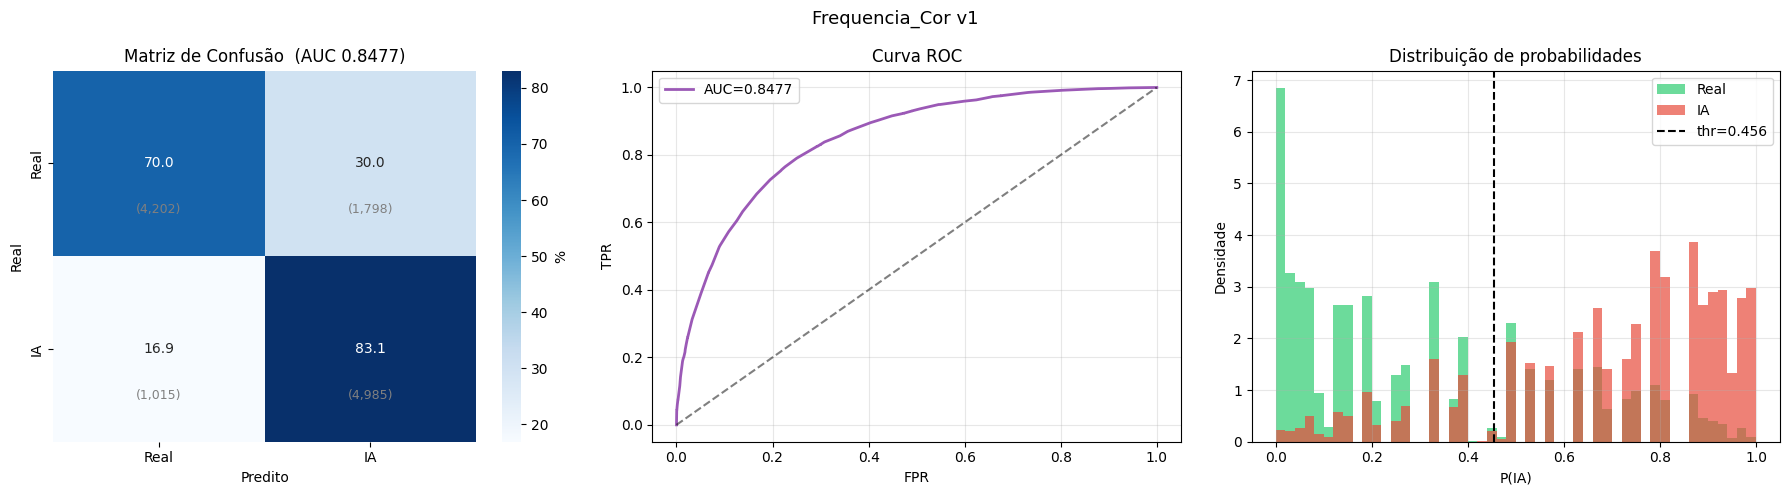

FP (Real->IA): 1798 (30.0%)
FN (IA->Real): 1015 (16.9%)
incerteza 35-65%: 18.8%


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm     = confusion_matrix(y_test, y_pred_test)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
            xticklabels=['Real', 'IA'], yticklabels=['Real', 'IA'],
            cbar_kws={'label': '%'})
for i in range(2):
    for j in range(2):
        axes[0].text(j+0.5, i+0.75, f'({cm[i,j]:,})',
                     ha='center', va='center', fontsize=9, color='gray')
axes[0].set_title(f'Matriz de Confusão  (AUC {auc:.4f})')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predito')

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr, tpr, color='#9b59b6', linewidth=2, label=f'AUC={auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].hist(proba_test[y_test==0], bins=50, alpha=0.7, color='#2ecc71', label='Real', density=True)
axes[2].hist(proba_test[y_test==1], bins=50, alpha=0.7, color='#e74c3c', label='IA',   density=True)
axes[2].axvline(best_thr, color='black', linestyle='--', label=f'thr={best_thr:.3f}')
axes[2].set_xlabel('P(IA)'); axes[2].set_ylabel('Densidade')
axes[2].set_title('Distribuição de probabilidades')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Frequencia_Cor v1', fontsize=13)
plt.tight_layout()
plt.savefig(CACHE_DIR / 'resultados_freq_cor_v1.png', dpi=120, bbox_inches='tight')
plt.show()

fn = cm[0, 1]
fp = cm[1, 0]
print(f'FP (Real->IA): {fn} ({fn/cm[0].sum()*100:.1f}%)')
print(f'FN (IA->Real): {fp} ({fp/cm[1].sum()*100:.1f}%)')
print(f'incerteza 35-65%: {((proba_test > 0.35) & (proba_test < 0.65)).mean()*100:.1f}%')

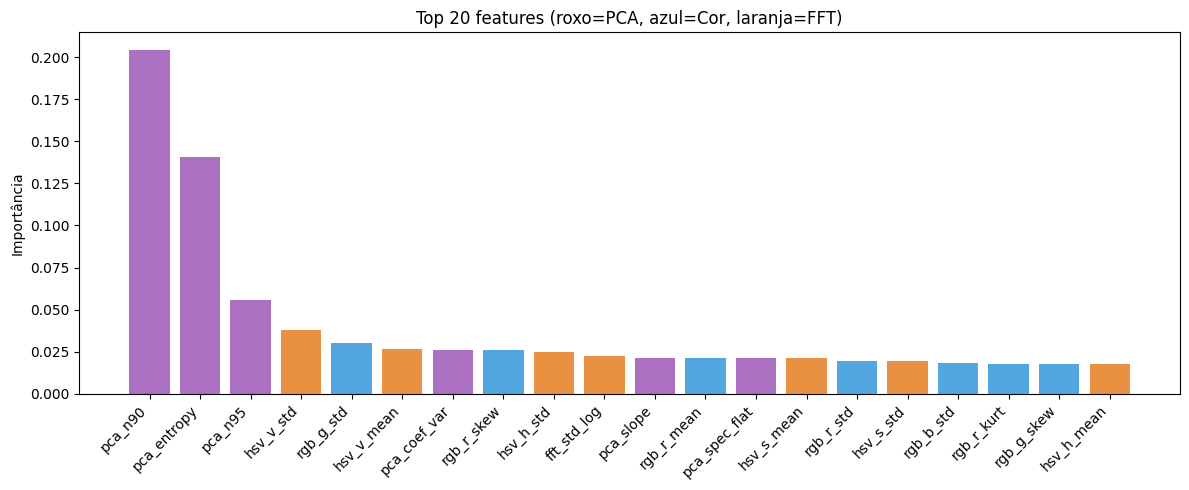

In [14]:
feature_names = (
    ['pca_entropy', 'pca_top5_ratio', 'pca_n50', 'pca_n90', 'pca_n95', 'pca_slope'] +
    ['pca_spec_flat', 'pca_first_dom', 'pca_coef_var', 'pca_rec_k5', 'pca_rec_k10', 'pca_rec_k20'] +
    [f'rgb_{ch}_{s}' for ch in ['r','g','b'] for s in ['mean','std','skew','kurt']] +
    [f'hsv_{ch}_{s}' for ch in ['h','s','v'] for s in ['mean','std']] +
    ['fft_low', 'fft_mid', 'fft_high', 'fft_ratio_hl', 'fft_std_log']
)

importances = xgb_model.feature_importances_
top_idx     = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 5))
colors = ['#9b59b6' if i < 12 else ('#3498db' if i < 24 else '#e67e22') for i in top_idx]
plt.bar(range(20), importances[top_idx], color=colors, alpha=0.85)
plt.xticks(range(20), [feature_names[i] for i in top_idx], rotation=45, ha='right')
plt.title('Top 20 features (roxo=PCA, azul=Cor, laranja=FFT)')
plt.ylabel('Importância')
plt.tight_layout()
plt.savefig(CACHE_DIR / 'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Salvar modelos

In [15]:
modelo_path    = OUTPUT_DIR / 'modelo_freq_cor_v1.pkl'
scaler_path    = OUTPUT_DIR / 'scaler_freq_cor.pkl'
threshold_path = OUTPUT_DIR / 'threshold.json'

joblib.dump({'xgb_model': xgb_model, 'calibrator': calibrator}, modelo_path)
joblib.dump(scaler, scaler_path)

with open(threshold_path, 'w') as f:
    json.dump({'threshold': best_thr, 'f1_val': best_f1, 'auc_test': auc}, f, indent=2)

print(f'salvos em {OUTPUT_DIR}')
print(json.dumps({'threshold': best_thr, 'f1_val': best_f1, 'auc_test': auc}, indent=2))

salvos em C:\Users\user\Desktop\TCC\Xiz9\modelos\Frequencia_Cor
{
  "threshold": 0.4555555582046509,
  "f1_val": 0.811574233551,
  "auc_test": 0.8477455277777779
}
